In [1]:
import pandas as pd
import numpy as np

In [2]:
Converted_Fare=pd.read_excel("../Data/BUS/Converted_Fare.xlsx",engine="openpyxl")

In [3]:
# 选择上下车站都在同一个区的路线
Converted_Fare=Converted_Fare[Converted_Fare['ON_DISTRICT']==Converted_Fare['OFF_DISTRICT']]


# 计算每个组的OFF_SEQ - ON_SEQ值
Converted_Fare['SEQ_DIFF'] = np.abs(Converted_Fare['OFF_SEQ'] - Converted_Fare['ON_SEQ'])

# 找到每个组中SEQ_DIFF最大值所对应的行的索引
idx = Converted_Fare.groupby(['ROUTE_ID', 'ROUTE_SEQ', 'PRICE','ON_DISTRICT'])['SEQ_DIFF'].idxmax()

# 使用这些索引来获取每个组中SEQ_DIFF最大值所对应的数据c
result = Converted_Fare.loc[idx].drop(columns=['SEQ_DIFF'])


In [4]:
Selected=result.copy()

In [5]:
Selected=Selected.drop(columns=['LAST_UPDATE_DATE','STOP_SEQ_x','STOP_SEQ_y'])
Selected=Selected.rename(columns={'ON_SEQ_STOP_Y':'ON_STOP_Y','OFF_SEQ_STOP_Y':'OFF_STOP_Y','ON_SEQ_STOP_X':'ON_STOP_X','OFF_SEQ_STOP_X':'OFF_STOP_X'})
Selected

,ROUTE_ID,ROUTE_SEQ,ON_SEQ,OFF_SEQ,PRICE,ROUTE_NAMES,COMPANY_CODE,SERVICE_MODE,SPECIAL_TYPE,STOP_NAMES_x,ON_SEQ_STOP_ID,STOP_NAMES_y,OFF_SEQ_STOP_ID,ON_STOP_X,ON_STOP_Y,OFF_STOP_X,OFF_STOP_Y,ON_DISTRICT,OFF_DISTRICT
271,1001,1,17,25,5.8,1,KMB,R,0,旺角奶路臣街,7036,尖沙咀码头,4025,835531,819900,835463,817244,油尖旺,油尖旺
152,1001,1,8,14,6.7,1,KMB,R,0,九龙寨城公园,4008,拔萃男书院,4014,837429,821474,836023,820663,九龍城,九龍城
254,1001,1,15,25,6.7,1,KMB,R,0,协和小学,4015,尖沙咀码头,4025,835862,820632,835463,817244,油尖旺,油尖旺
5,1001,1,1,7,6.7,1,KMB,R,0,竹园邨总站,4001,盈东楼,8090,837872,822918,837727,821666,黃大仙,黃大仙
525,1001,2,13,17,6.3,1,KMB,R,0,明爱太子宿舍,4077,东宝庭道,4039,836322,820884,837258,821296,九龍城,九龍城
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
755777,1000575,1,1,18,5.1,272A,KMB,R,0,大学站,6236,大学站,6236,839753,830365,839753,830365,沙田,沙田
729030,1000587,1,16,17,5.4,270B,KMB,T,1,上水转车站 - 上水站,6626,上水转车站 - 上水总站,6625,831178,840270,831219,840332,北區,北區
729025,1000587,1,14,15,16.9,270B,KMB,T,1,青沙公路转车站,13378,青沙公路转车站,13185,834816,824550,834844,824598,沙田,沙田
728206,1000587,1,1,6,16.9,270B,KMB,T,1,奥运站巴士总站,9048,太子站,9077,834607,819986,835345,820751,油尖旺,油尖旺


In [6]:
# Use Manhattan distance instead because HK roads are
#  planned and constructed in blocks intead of using euclean distance

Selected['DISTANCE'] = abs(Selected['ON_STOP_X'] - Selected['OFF_STOP_X']) + abs(Selected['ON_STOP_Y'] - Selected['OFF_STOP_Y'])

### Justification for Reasonable price<10

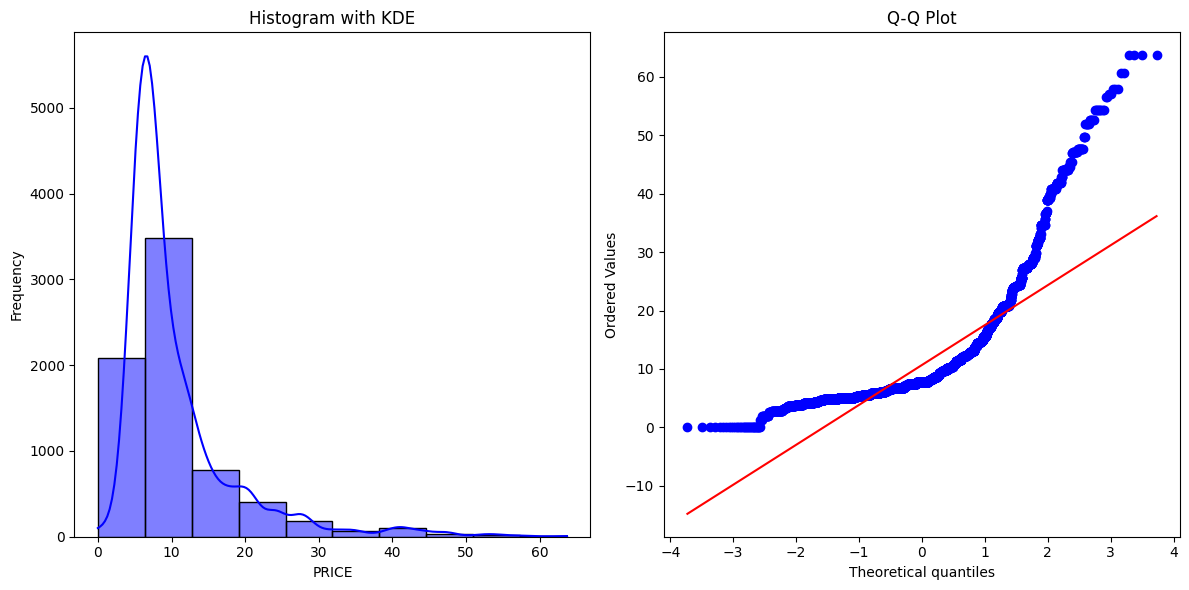

In [7]:
import seaborn as sns
from scipy import stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 直方图 + KDE
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)  # 第一个子图
sns.histplot(Selected['PRICE'], kde=True, color='blue', bins=10)
plt.title('Histogram with KDE')
plt.xlabel('PRICE')
plt.ylabel('Frequency')

# 2. Q-Q 图
plt.subplot(1, 2, 2)  # 第二个子图
stats.probplot(Selected['PRICE'], dist="norm", plot=plt)
plt.title('Q-Q Plot')

# 显示图形
plt.tight_layout()
plt.show()

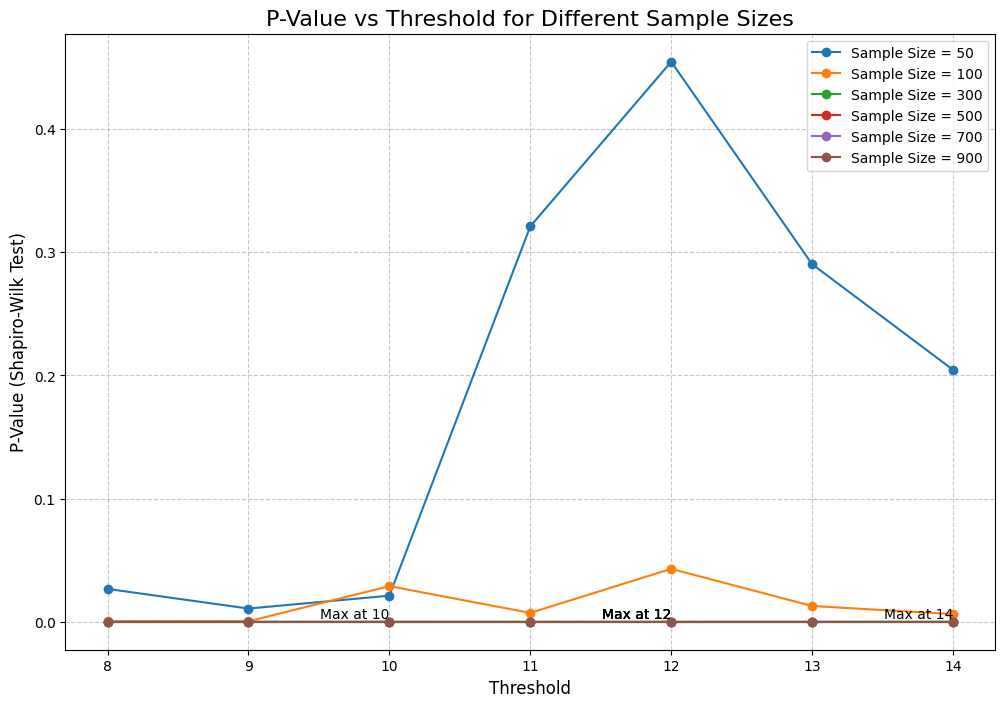

Thresholds with Maximum P-Value for Each Sample Size:
Sample Size = 50: Threshold = 12
Sample Size = 100: Threshold = 12
Sample Size = 300: Threshold = 10
Sample Size = 500: Threshold = 14
Sample Size = 700: Threshold = 12
Sample Size = 900: Threshold = 12


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro




# 定义 threshold 范围和抽样数
thresholds = range(8, 15)
sample_sizes = [50,100, 300, 500, 700, 900]

# 创建图形
plt.figure(figsize=(12, 8))
import random

# 存储每个抽样数下 p_value 最大值对应的 threshold
max_p_value_thresholds = {}

# 遍历抽样数
for sample_size in sample_sizes:
    p_values = []  # 存储每个 threshold 对应的 p_value
    
    # 遍历 threshold
    for threshold in thresholds:
        # 筛选数据
        filtered_data = Selected[Selected['PRICE'] < threshold]['PRICE']
        
        # 如果数据量超过抽样数，则随机抽样
        if len(filtered_data) > sample_size:
            filtered_data = filtered_data.sample(n=sample_size,random_state=42)
        
        # 进行 Shapiro-Wilk 正态性检验
        stat, p_value = shapiro(filtered_data)
        p_values.append(p_value)
    
    # 绘制折线图
    plt.plot(thresholds, p_values, marker='o', label=f'Sample Size = {sample_size}')
    

    max_p_value_index = np.argmax(p_values)
    max_p_value_thresholds[sample_size] = thresholds[max_p_value_index]


for sample_size, threshold in max_p_value_thresholds.items():
    plt.text(threshold, max(p_values), f'Max at {threshold}', fontsize=10, ha='right', va='bottom')

# 设置图形标题和标签
plt.title('P-Value vs Threshold for Different Sample Sizes', fontsize=16)
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('P-Value (Shapiro-Wilk Test)', fontsize=12)
plt.xticks(thresholds)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

# 显示图形
plt.show()

# 打印每个抽样数下 p_value 最大值对应的 threshold
print("Thresholds with Maximum P-Value for Each Sample Size:")
for sample_size, threshold in max_p_value_thresholds.items():
    print(f"Sample Size = {sample_size}: Threshold = {threshold}")

In [9]:
Selected

,ROUTE_ID,ROUTE_SEQ,ON_SEQ,OFF_SEQ,PRICE,ROUTE_NAMES,COMPANY_CODE,SERVICE_MODE,SPECIAL_TYPE,STOP_NAMES_x,ON_SEQ_STOP_ID,STOP_NAMES_y,OFF_SEQ_STOP_ID,ON_STOP_X,ON_STOP_Y,OFF_STOP_X,OFF_STOP_Y,ON_DISTRICT,OFF_DISTRICT,DISTANCE
271,1001,1,17,25,5.8,1,KMB,R,0,旺角奶路臣街,7036,尖沙咀码头,4025,835531,819900,835463,817244,油尖旺,油尖旺,2724
152,1001,1,8,14,6.7,1,KMB,R,0,九龙寨城公园,4008,拔萃男书院,4014,837429,821474,836023,820663,九龍城,九龍城,2217
254,1001,1,15,25,6.7,1,KMB,R,0,协和小学,4015,尖沙咀码头,4025,835862,820632,835463,817244,油尖旺,油尖旺,3787
5,1001,1,1,7,6.7,1,KMB,R,0,竹园邨总站,4001,盈东楼,8090,837872,822918,837727,821666,黃大仙,黃大仙,1397
525,1001,2,13,17,6.3,1,KMB,R,0,明爱太子宿舍,4077,东宝庭道,4039,836322,820884,837258,821296,九龍城,九龍城,1348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
755777,1000575,1,1,18,5.1,272A,KMB,R,0,大学站,6236,大学站,6236,839753,830365,839753,830365,沙田,沙田,0
729030,1000587,1,16,17,5.4,270B,KMB,T,1,上水转车站 - 上水站,6626,上水转车站 - 上水总站,6625,831178,840270,831219,840332,北區,北區,103
729025,1000587,1,14,15,16.9,270B,KMB,T,1,青沙公路转车站,13378,青沙公路转车站,13185,834816,824550,834844,824598,沙田,沙田,76
728206,1000587,1,1,6,16.9,270B,KMB,T,1,奥运站巴士总站,9048,太子站,9077,834607,819986,835345,820751,油尖旺,油尖旺,1503


In [15]:
percentiles = Selected['PRICE'].rank(pct=True) * 100

# 找到值为 10 的百分位数
value = 12
percentile_of_value = percentiles[Selected['PRICE'] == value].values[0]

print(f"值为 {value} 的百分位数是: {percentile_of_value:.2f}%")

值为 12 的百分位数是: 73.74%


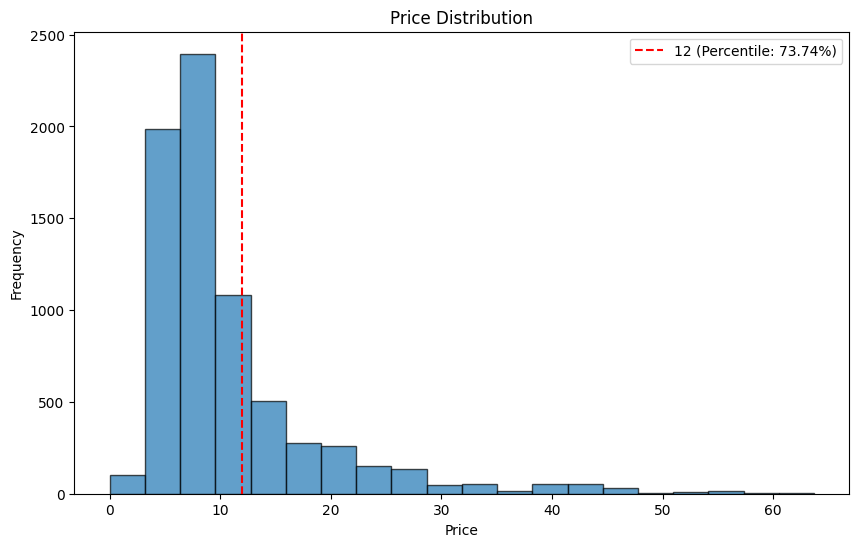

In [16]:
# 绘制直方图
plt.figure(figsize=(10, 6))
plt.hist(Selected['PRICE'], bins=20, edgecolor='black', alpha=0.7)

# 标记值为 10 的位置
plt.axvline(x=value, color='red', linestyle='--', label=f'{value} (Percentile: {percentile_of_value:.2f}%)')

# 添加标题和标签
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.legend()

# 显示图表
plt.show()

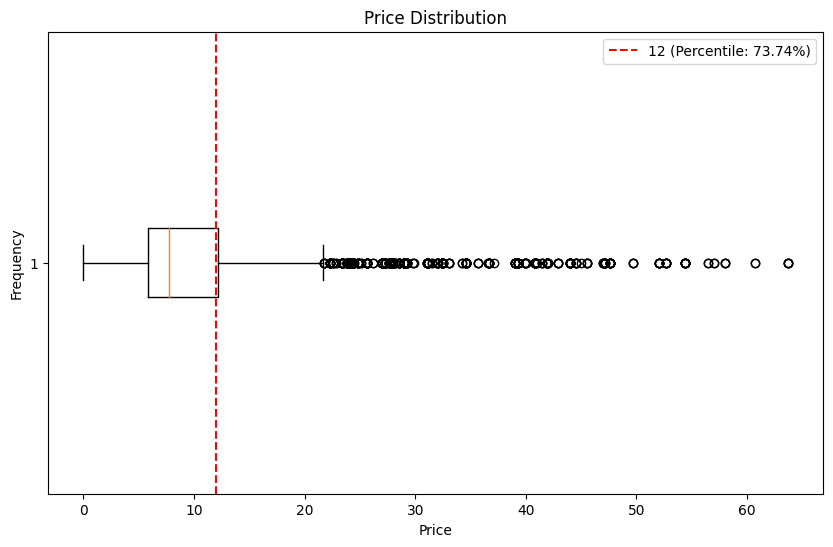

In [17]:
# 绘制箱线图
plt.figure(figsize=(10, 6))
plt.boxplot(Selected['PRICE'], vert=False)

# 标记值为 10 的位置
plt.axvline(x=value, color='red', linestyle='--', label=f'{value} (Percentile: {percentile_of_value:.2f}%)')

# 添加标题和标签
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.legend()

# 显示图表
plt.show()c

In [7]:
#筛选出合理的范围：
#假设区之间人们只要PRICE<10都接受
Selected=Selected[Selected['PRICE']<10]

#筛选Distance不为0的路线
Selected=Selected[Selected['DISTANCE']!=0]
# 计算每个区域的总距离
district_total_distance = Selected.groupby("ON_DISTRICT")["DISTANCE"].transform("sum")

# 计算成本指数
Selected["COST_INDEX"] = (Selected["PRICE"] * Selected["DISTANCE"]) / district_total_distance

In [1]:
district_mean_cost = Selected.groupby('ON_DISTRICT')['COST_INDEX'].mean().reset_index()
district_mean_cost['COST_INDEX']=district_mean_cost['COST_INDEX']*100

district_mean_cost.rename(columns={'COST_INDEX': 'MEAN_COST_INDEX(%)'}, inplace=True)

district_counts = Selected.groupby('ON_DISTRICT').size().reset_index(name='NUMBER_ROUTES')

# Merge the counts into the district_mean_cost DataFrame
district_mean_cost = district_mean_cost.merge(district_counts, on='ON_DISTRICT')
print(district_mean_cost)

NameError: name 'Selected' is not defined

In [33]:
result=district_mean_cost

In [34]:
Selected.to_excel("../Data/BUS/SelectedRoute.xlsx",engine='openpyxl')
result.to_excel("../Data/BUS/Cost_index_18.xlsx",engine="openpyxl")